In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE

import nltk
from nltk.corpus import opinion_lexicon
from gensim.models import Word2Vec

nltk.download("opinion_lexicon")

lib = pd.read_csv("LIB.csv")
corpus = pd.read_csv("CORPUS.csv")
vocab = pd.read_csv("VOCAB.csv")
bow = pd.read_csv("BOW.csv")
dtm = pd.read_csv("DTM.csv", index_col=0)
tfidf_l2 = pd.read_csv("TFIDF_L2.csv", index_col=0)

pca_dcm = pd.read_csv("PCA_DCM.csv")
loadings = pd.read_csv("PCA_LOADINGS.csv", index_col=0)

LDA_THETA = pd.read_csv("LDA_THETA.csv")
LDA_PHI = pd.read_csv("LDA_PHI.csv", index_col=0)

DOC_SENT = pd.read_csv("DOC_SENT.csv")
VOCAB_W2V = pd.read_csv("VOCAB_W2V.csv")

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/mta/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


## PCA Components

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_pca = pca.fit_transform(tfidf_l2)

In [3]:
components = pd.DataFrame(
    pca.components_,
    columns=tfidf_l2.columns
)

In [4]:
top_pos_pc1 = (
    components.iloc[0]
    .sort_values(ascending=False)
    .head(5)
)

top_pos_pc1

governor    0.147615
cried       0.088378
village     0.085647
lady        0.084859
woman       0.084152
Name: 0, dtype: float64

In [5]:
pca.explained_variance_ratio_

array([0.05671484, 0.03754063, 0.03502982, 0.03010863, 0.02785909])

In [6]:
top_neg_pc2 = (
    components.iloc[1]  
    .sort_values()       
    .head(5)
)

top_neg_pc2

sea       -0.137232
village   -0.118300
works     -0.102223
water     -0.097193
storm     -0.091454
Name: 1, dtype: float64

## PCA DCM

In [7]:
pca_dcm = pd.DataFrame(
    X_pca,
    index=tfidf_l2.index,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

pca_dcm.head()

,PC1,PC2,PC3,PC4,PC5
doc_id,,,,,
DOC001,-0.275037,0.131178,0.028840,-0.059398,0.279626
DOC002,-0.089319,0.095318,0.259978,-0.006979,0.357883
DOC003,-0.207670,0.085688,0.033382,0.267986,0.269892
DOC004,-0.329902,-0.164888,-0.176051,0.302643,0.047757
DOC005,-0.260711,0.051464,0.052685,0.038870,0.290375


In [8]:
pca_dcm = pca_dcm.reset_index().rename(columns={"index": "doc_id"})

pca_dcm = pca_dcm.merge(
    lib[["doc_id", "author", "title"]],
    on="doc_id",
    how="left"
)

pca_dcm.head()

,doc_id,PC1,PC2,PC3,PC4,PC5,author,title
0,DOC001,-0.275037,0.131178,0.028840,-0.059398,0.279626,Edgar Allan Poe,The Purloined Letter
1,DOC002,-0.089319,0.095318,0.259978,-0.006979,0.357883,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade
2,DOC003,-0.207670,0.085688,0.033382,0.267986,0.269892,Edgar Allan Poe,The Black Cat
3,DOC004,-0.329902,-0.164888,-0.176051,0.302643,0.047757,Edgar Allan Poe,A Descent Into The Maelstrom
4,DOC005,-0.260711,0.051464,0.052685,0.038870,0.290375,Edgar Allan Poe,Von Kempelen And His Discovery


In [9]:
pca_dcm.to_csv("PCA_DCM.csv", index=False)

## PCA Loadings

In [10]:
loadings = pd.DataFrame(
    pca.components_,
    columns=tfidf_l2.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings.head()

,laid,wonder,gaze,fresh,touch,followed,filled,evidently,ere,ear,...,nearly,small,days,certain,right,feet,whether,threw,truth,suddenly
PC1,0.026473,-0.002608,0.017389,0.021273,0.002376,-0.005941,-0.007619,-0.007785,0.008564,0.017534,...,-0.040363,-0.008886,-0.007647,-0.025289,-0.008594,-0.015928,0.014672,0.002033,-0.011509,-0.009946
PC2,0.006298,0.003014,-0.003037,-0.023139,-0.002083,0.028703,0.002313,0.009701,0.005661,0.003883,...,0.010301,-0.017721,-0.004785,0.004897,-0.003802,-0.019380,-0.003399,0.010580,0.011503,0.003178
PC3,-0.011634,-0.024760,-0.001188,-0.016118,-0.008829,-0.013927,-0.001825,-0.012414,-0.018555,-0.012590,...,-0.014342,-0.010643,-0.007303,-0.004838,-0.005743,-0.020825,-0.009588,-0.009414,-0.012119,-0.012710
PC4,-0.025110,-0.021557,-0.005577,-0.010297,-0.003746,-0.009884,-0.006228,0.002456,0.015448,-0.007054,...,0.007362,0.022700,0.008228,-0.012684,-0.000017,0.024326,-0.019959,0.005018,-0.008813,0.006919
PC5,0.008970,-0.008590,-0.001932,0.022172,-0.023034,-0.021225,0.005524,0.007067,-0.006628,-0.017281,...,0.013403,0.006778,-0.005326,0.014374,0.004191,0.007747,0.031685,-0.005617,0.008358,-0.024047


In [11]:
loadings.to_csv("PCA_LOADINGS.csv")

In [12]:
loadings.loc["PC1"].sort_values(ascending=False).head(10)

governor    0.147615
cried       0.088378
village     0.085647
lady        0.084859
woman       0.084152
street      0.081624
merry       0.081173
children    0.075250
ye          0.073131
sir         0.071554
Name: PC1, dtype: float64

In [13]:
loadings.loc["PC1"].sort_values().head(10)

although     -0.110833
minutes      -0.108087
condition    -0.089707
works        -0.082137
moon         -0.077413
wall         -0.077400
reason       -0.076336
matter       -0.073639
difficulty   -0.070471
impossible   -0.068233
Name: PC1, dtype: float64

In [14]:
loadings.loc["PC2"].sort_values(ascending=False).head(10)
loadings.loc["PC2"].sort_values().head(10)

sea          -0.137232
village      -0.118300
works        -0.102223
water        -0.097193
storm        -0.091454
foundation   -0.088565
road         -0.083228
winter       -0.076841
summer       -0.075430
sky          -0.071952
Name: PC2, dtype: float64

## PCA Visualization 1

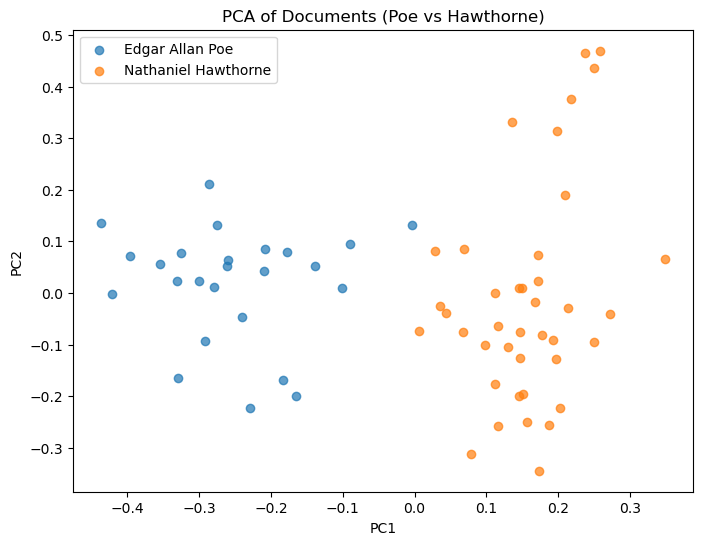

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for author in pca_dcm["author"].unique():
    subset = pca_dcm[pca_dcm["author"] == author]
    plt.scatter(subset["PC1"], subset["PC2"], label=author, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Documents (Poe vs Hawthorne)")
plt.legend()
plt.show()

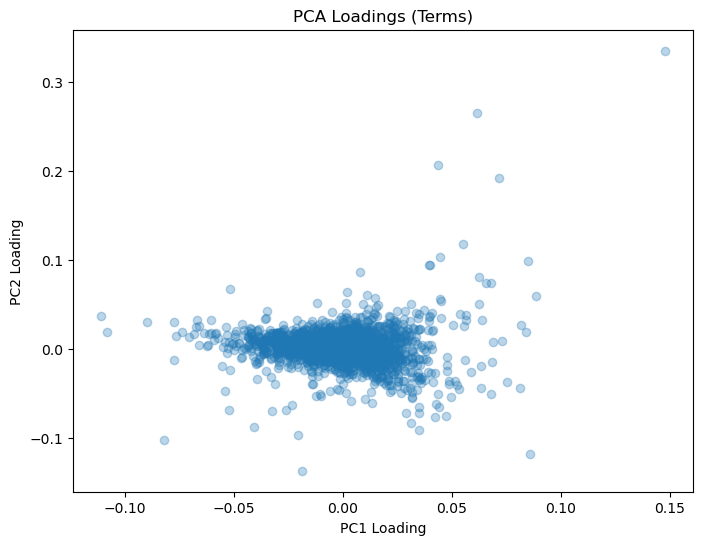

In [16]:
plt.figure(figsize=(8,6))

x = loadings.loc["PC1"]
y = loadings.loc["PC2"]

plt.scatter(x, y, alpha=0.3)

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("PCA Loadings (Terms)")
plt.show()

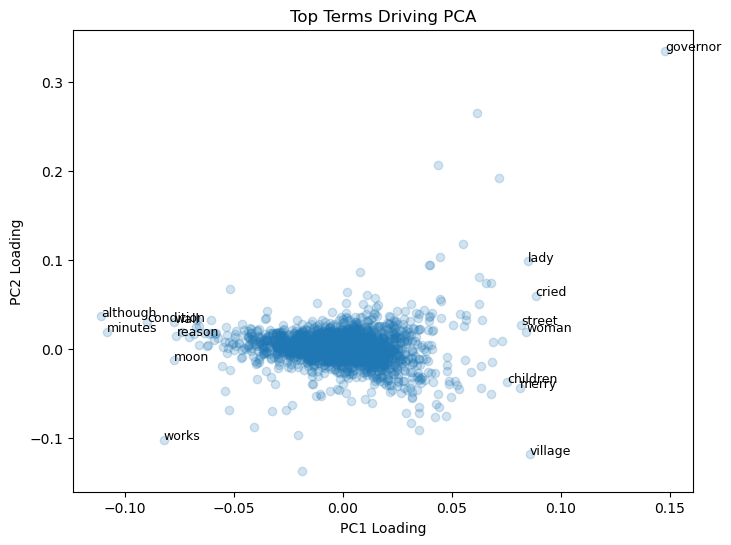

In [17]:
top_terms = loadings.loc["PC1"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.2)

for term in top_terms:
    plt.text(x[term], y[term], term, fontsize=9)

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("Top Terms Driving PCA")
plt.show()

## PCA Visualization 2 (4)

Include a scatterplot of documents in the space created by the second two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

(INSERT IMAGE HERE)

(INSERT IMAGE HERE)

Briefly describe the nature of the polarity you see in the second component:

(INSERT DESCRIPTION HERE)

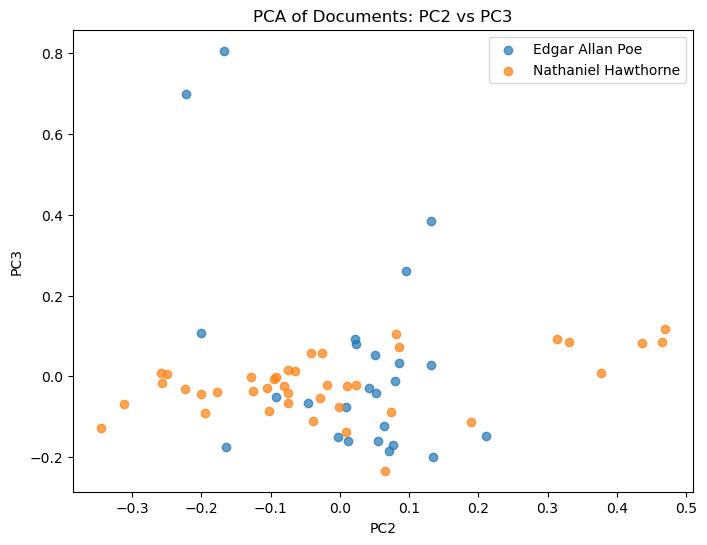

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for author in pca_dcm["author"].unique():
    subset = pca_dcm[pca_dcm["author"] == author]
    plt.scatter(subset["PC2"], subset["PC3"], label=author, alpha=0.7)

plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PCA of Documents: PC2 vs PC3")
plt.legend()
plt.show()

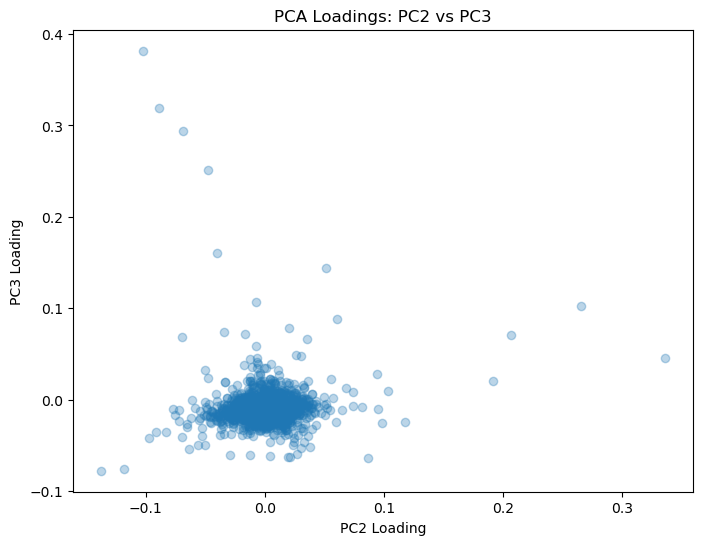

In [19]:
x = loadings.loc["PC2"]
y = loadings.loc["PC3"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.3)

plt.xlabel("PC2 Loading")
plt.ylabel("PC3 Loading")
plt.title("PCA Loadings: PC2 vs PC3")
plt.show()

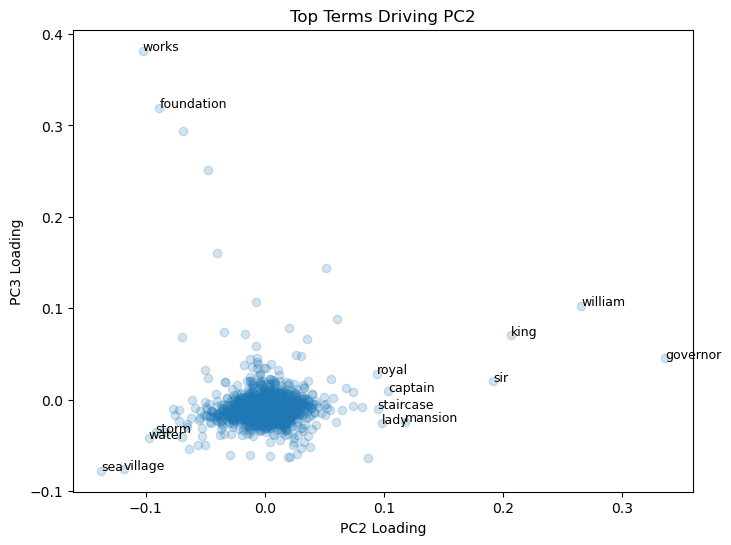

In [20]:
top_terms = loadings.loc["PC2"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.2)

for term in top_terms:
    plt.text(x[term], y[term], term, fontsize=9)

plt.xlabel("PC2 Loading")
plt.ylabel("PC3 Loading")
plt.title("Top Terms Driving PC2")
plt.show()

## LDA TOPIC

In [21]:
corpus_filt = corpus[
    (corpus["pos_group"].isin(["NOUN", "VERB"])) &
    (corpus["term_str"].str.len() > 2)
]

In [22]:
dtm_counts = corpus_filt.groupby(["doc_id", "term_str"]).size().unstack(fill_value=0)

In [23]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=10
)

lda.fit(dtm_counts)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [24]:
import numpy as np

terms = dtm_counts.columns

def get_top_words(model, terms, n=5):
    topics = {}
    for i, comp in enumerate(model.components_):
        top_idx = np.argsort(comp)[-n:]
        topics[f"T{i:02d}"] = [terms[j] for j in top_idx]
    return topics

topics = get_top_words(lda, terms, n=5)
topics

{'T00': ['dost', 'gold-bug', 'balloon-hoax', 'portrayed', 'retributions'],
 'T01': ['been', 'have', 'were', 'had', 'was'],
 'T02': ['were', 'been', 'have', 'had', 'was'],
 'T03': ['are', 'works', 'work', 'gutenberg', 'project'],
 'T04': ['were', 'are', 'have', 'had', 'was']}

## LDA THETA

In [25]:
theta = lda.transform(dtm_counts)

LDA_THETA = pd.DataFrame(
    theta,
    index=dtm_counts.index,
    columns=[f"T{i:02d}" for i in range(theta.shape[1])]
)

LDA_THETA = LDA_THETA.reset_index().rename(columns={"index": "doc_id"})

LDA_THETA = LDA_THETA.merge(
    lib[["doc_id", "author", "title"]],
    on="doc_id",
    how="left"
)

LDA_THETA.head()

,doc_id,T00,T01,T02,T03,T04,author,title
0,DOC001,0.000079,0.000080,0.999682,0.000079,0.000080,Edgar Allan Poe,The Purloined Letter
1,DOC002,0.000744,0.590485,0.364174,0.043828,0.000769,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade
2,DOC003,0.000114,0.000116,0.490589,0.000115,0.509066,Edgar Allan Poe,The Black Cat
3,DOC004,0.000081,0.000083,0.999672,0.000081,0.000083,Edgar Allan Poe,A Descent Into The Maelstrom
4,DOC005,0.000195,0.000199,0.999210,0.000198,0.000198,Edgar Allan Poe,Von Kempelen And His Discovery


In [26]:
LDA_THETA.to_csv("LDA_THETA.csv", index=False)

In [27]:
LDA_THETA[[f"T{i:02d}" for i in range(theta.shape[1])]].sum(axis=1).head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64

## LDA PHI

In [28]:
import numpy as np

phi = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]

In [29]:
LDA_PHI = pd.DataFrame(
    phi,
    columns=dtm_counts.columns,
    index=[f"T{i:02d}" for i in range(phi.shape[0])]
)

LDA_PHI.head()

term_str,-lantern,....,.....,.fleet,621-9288,:188,_a_,_ab,_abandon_,_absurdities_,...,æolus,æronaut,æronauts,ærostation,æsop,ætna,émeutes,œil_,γελαξμα,λαξμ
T00,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,...,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057,0.000057
T01,0.000022,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000022,0.000002,0.000002,0.000002,0.000002
T02,0.000003,0.000112,0.000019,0.000019,0.000003,0.000019,0.000019,0.000019,0.000034,0.000003,...,0.000003,0.000034,0.000019,0.000019,0.000003,0.000003,0.000019,0.000019,0.000003,0.000003
T03,0.000023,0.000023,0.000023,0.000023,0.000249,0.000023,0.000023,0.000023,0.000023,0.000023,...,0.000136,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023,0.000023
T04,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000044,...,0.000007,0.000007,0.000007,0.000007,0.000080,0.000007,0.000007,0.000007,0.000044,0.000044


In [30]:
LDA_PHI.to_csv("LDA_PHI.csv")

In [31]:
LDA_PHI.sum(axis=1)

T00    1.0
T01    1.0
T02    1.0
T03    1.0
T04    1.0
dtype: float64

## LDA + PCA Visualization

In [32]:
from sklearn.decomposition import PCA

theta_only = LDA_THETA[[col for col in LDA_THETA.columns if col.startswith("T")]]

pca_topics = PCA(n_components=2, random_state=42)
topic_coords = pca_topics.fit_transform(theta_only.T)

In [33]:
topic_df = pd.DataFrame(
    topic_coords,
    columns=["PC1", "PC2"],
    index=theta_only.columns
).reset_index().rename(columns={"index": "topic"})

In [34]:
topic_sizes = theta_only.mean(axis=0)

topic_df["size"] = topic_df["topic"].map(topic_sizes)

In [35]:
dominant_author = {}

for topic in theta_only.columns:
    weights = LDA_THETA[[topic, "author"]]
    dominant_author[topic] = weights.groupby("author")[topic].mean().idxmax()

topic_df["author"] = topic_df["topic"].map(dominant_author)

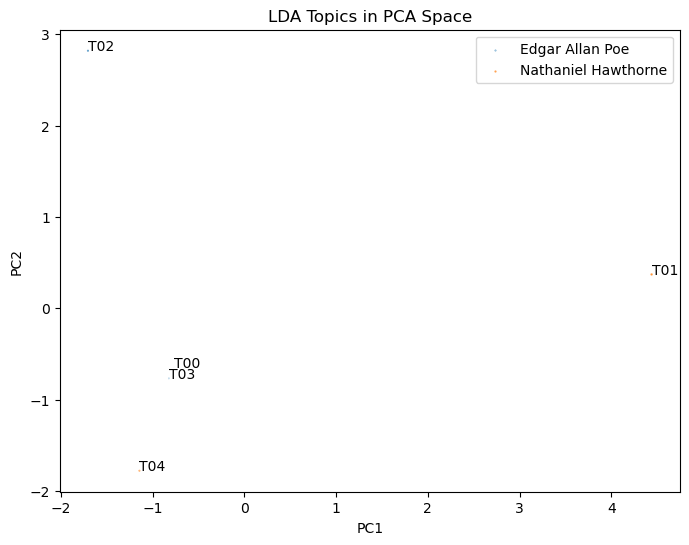

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for author in topic_df["author"].unique():
    subset = topic_df[topic_df["author"] == author]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=subset["size"],
        label=author,
        alpha=0.7
    )

for i, row in topic_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["topic"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LDA Topics in PCA Space")
plt.legend()
plt.show()

## Sentiment VOCAB_SENT

In [37]:
import nltk
from nltk.corpus import opinion_lexicon

nltk.download("opinion_lexicon")

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/mta/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


True

In [38]:
positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())

In [39]:
VOCAB_SENT = vocab[vocab["term_str"].isin(positive_words | negative_words)].copy()

VOCAB_SENT["sentiment"] = VOCAB_SENT["term_str"].apply(
    lambda x: "positive" if x in positive_words else "negative"
)

VOCAB_SENT["sentiment_value"] = VOCAB_SENT["sentiment"].map({
    "positive": 1,
    "negative": -1
})

VOCAB_SENT = VOCAB_SENT[
    ["term_str", "sentiment", "sentiment_value", "n", "df", "dfidf"]
]

VOCAB_SENT.head()

,term_str,sentiment,sentiment_value,n,df,dfidf
30,abnormal,negative,-1,6,5,18.502199
34,abominable,negative,-1,5,4,16.089471
35,abomination,negative,-1,2,2,10.044736
39,abound,positive,1,2,1,6.022368
42,abounds,positive,1,2,2,10.044736


In [40]:
VOCAB_SENT.to_csv("VOCAB_SENT.csv", index=False)

In [41]:
VOCAB_SENT["sentiment"].value_counts()

sentiment
negative    1903
positive    1010
Name: count, dtype: int64

In [42]:
len(VOCAB_SENT)

2913

## Sentiment BOW_SENT

In [43]:
BOW_SENT = bow.merge(
    VOCAB_SENT[["term_str", "sentiment_value"]],
    on="term_str",
    how="inner"
)

In [44]:
BOW_SENT["sent_count"] = BOW_SENT["n"] * BOW_SENT["sentiment_value"]

In [45]:
doc_sentiment = BOW_SENT.groupby("doc_id")["sent_count"].sum().reset_index()
doc_sentiment.head()

,doc_id,sent_count
0,DOC001,-11
1,DOC002,11
2,DOC003,-14
3,DOC004,-82
4,DOC005,32


In [46]:
BOW_SENT.to_csv("BOW_SENT.csv", index=False)

In [47]:
BOW_SENT["sentiment_value"].value_counts()

sentiment_value
-1    9486
 1    6928
Name: count, dtype: int64

In [48]:
doc_sentiment.merge(lib, on="doc_id").groupby("author")["sent_count"].mean()

author
Edgar Allan Poe       -60.360
Nathaniel Hawthorne   -19.525
Name: sent_count, dtype: float64

## Sentiment DOC_SENT

In [49]:
DOC_SENT = (
    BOW_SENT
    .groupby("doc_id")
    .agg(
        sentiment_sum=("sent_count", "sum"),
        sentiment_words=("n", "sum")
    )
    .reset_index()
)

DOC_SENT = DOC_SENT.merge(
    lib[["doc_id", "author", "title", "n_words"]],
    on="doc_id",
    how="left"
)

DOC_SENT["sentiment_norm"] = DOC_SENT["sentiment_sum"] / DOC_SENT["n_words"]

DOC_SENT.head()

,doc_id,sentiment_sum,sentiment_words,author,title,n_words,sentiment_norm
0,DOC001,-11,391,Edgar Allan Poe,The Purloined Letter,6974,-0.001577
1,DOC002,11,49,Edgar Allan Poe,The Thousand-And-Second Tale Of Scheherazade,735,0.014966
2,DOC003,-14,344,Edgar Allan Poe,The Black Cat,4876,-0.002871
3,DOC004,-82,406,Edgar Allan Poe,A Descent Into The Maelstrom,6928,-0.011836
4,DOC005,32,160,Edgar Allan Poe,Von Kempelen And His Discovery,2768,0.011561


In [50]:
DOC_SENT.to_csv("DOC_SENT.csv", index=False)

In [51]:
DOC_SENT.groupby("author")[["sentiment_sum", "sentiment_norm"]].mean()

,sentiment_sum,sentiment_norm
author,,
Edgar Allan Poe,-60.360,-0.008982
Nathaniel Hawthorne,-19.525,-0.002900


## Sentiment Plot 

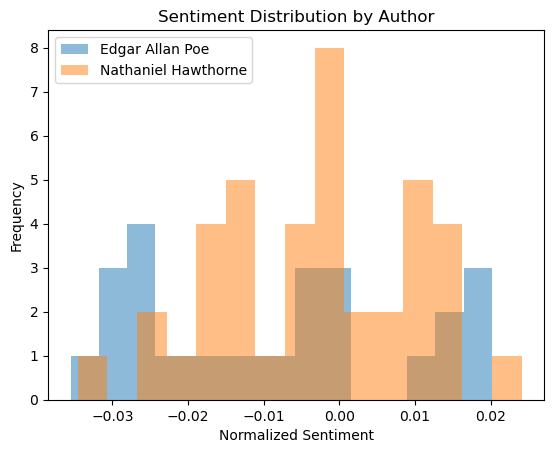

In [52]:
import matplotlib.pyplot as plt

for author in DOC_SENT["author"].unique():
    subset = DOC_SENT[DOC_SENT["author"] == author]
    plt.hist(subset["sentiment_norm"], alpha=0.5, label=author, bins=15)

plt.legend()
plt.title("Sentiment Distribution by Author")
plt.xlabel("Normalized Sentiment")
plt.ylabel("Frequency")
plt.show()

## VOCAB_W2V

In [53]:
from gensim.models import Word2Vec
sentences = corpus.groupby("doc_id")["term_str"].apply(list).tolist()

In [54]:
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=5,
    min_count=2,
    workers=4
)

In [55]:
import numpy as np

def get_vector(word):
    if word in w2v_model.wv:
        return w2v_model.wv[word]
    else:
        return np.zeros(50)

vectors = vocab["term_str"].apply(get_vector)

VOCAB_W2V = pd.DataFrame(vectors.tolist())
VOCAB_W2V.columns = [f"dim_{i}" for i in range(50)]

VOCAB_W2V["term_str"] = vocab["term_str"].values

VOCAB_W2V.head()

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_41,dim_42,dim_43,dim_44,dim_45,dim_46,dim_47,dim_48,dim_49,term_str
0,0.319989,-0.409965,-0.603245,-0.133174,-0.406621,-1.503522,0.899547,1.812532,-2.164412,-0.897645,...,-1.007758,-0.777056,0.257715,1.933632,-0.391077,-0.111709,-0.433436,1.116093,1.155635,a
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,aaraaf
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,aback
3,0.008062,0.006871,0.019543,-0.009851,0.000382,-0.013334,-0.041876,-0.000632,-0.071372,0.041487,...,-0.041848,-0.007866,0.039118,0.036822,-0.073977,-0.014074,-0.047238,0.004204,0.032819,abandon
4,-0.010476,0.000267,0.021478,-0.014222,0.032447,-0.045756,-0.016145,0.058972,-0.112576,-0.030264,...,-0.046146,-0.011389,0.034981,0.065296,-0.062688,-0.015767,-0.036706,0.040689,0.036718,abandoned


In [56]:
VOCAB_W2V.to_csv("VOCAB_W2V.csv", index=False)

## Word2vec tSNE Plot

In [57]:
words = vocab.sort_values("n", ascending=False)["term_str"].head(500)

vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
labels = [w for w in words if w in w2v_model.wv]

In [58]:
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X = tsne.fit_transform(np.array(vectors))

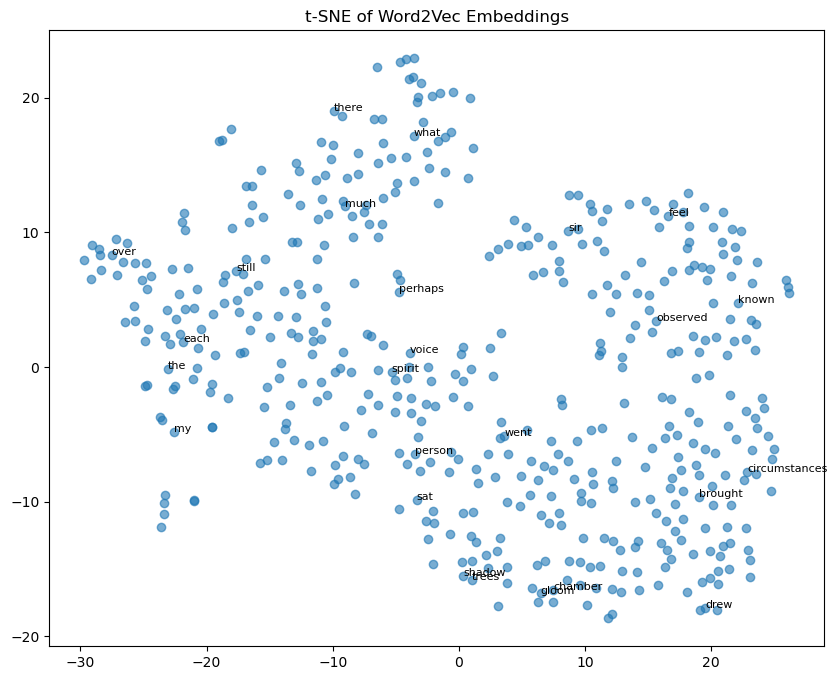

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(X[:,0], X[:,1], alpha=0.6)

# label a subset (not all, or it’s unreadable)
for i in range(0, len(labels), 20):
    plt.text(X[i,0], X[i,1], labels[i], fontsize=8)

plt.title("t-SNE of Word2Vec Embeddings")
plt.show()

# Riffs

## Riff 1 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

In [60]:
data = DOC_SENT.copy()
data.columns

Index(['doc_id', 'sentiment_sum', 'sentiment_words', 'author', 'title',
       'n_words', 'sentiment_norm'],
      dtype='object')

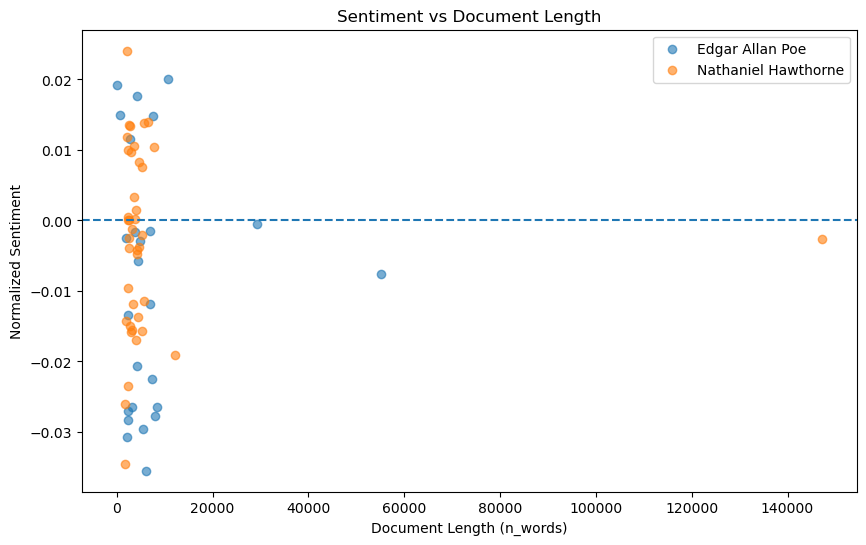

In [61]:
import matplotlib.pyplot as plt

data = DOC_SENT.copy()

plt.figure(figsize=(10,6))

for author in data["author"].unique():
    subset = data[data["author"] == author]
    plt.scatter(
        subset["n_words"],
        subset["sentiment_norm"],
        alpha=0.6,
        label=author
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Document Length (n_words)")
plt.ylabel("Normalized Sentiment")
plt.title("Sentiment vs Document Length")
plt.legend()
plt.show()

## Riff 2

In [62]:
top_terms = vocab.sort_values("dfidf", ascending=False)["term_str"].head(20)

In [63]:
dtm_subset = dtm[top_terms].copy()

In [64]:
dtm_subset["author"] = lib["author"].values

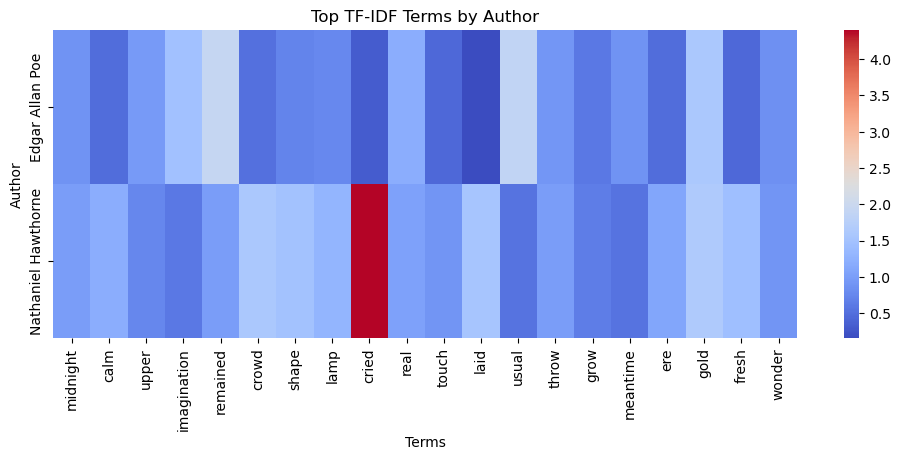

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

author_term = dtm_subset.groupby("author").mean()

plt.figure(figsize=(12,4))
sns.heatmap(author_term, cmap="coolwarm")

plt.title("Top TF-IDF Terms by Author")
plt.xlabel("Terms")
plt.ylabel("Author")
plt.show()

## Riff 3

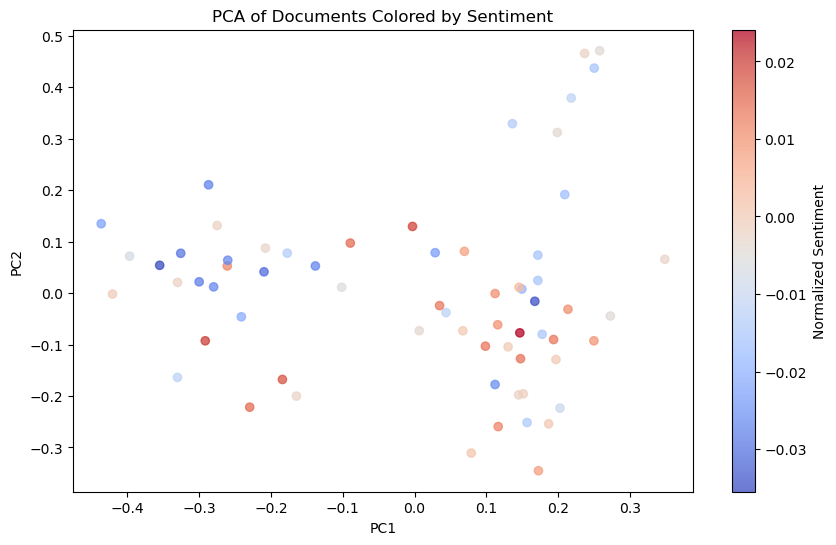

In [66]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
doc_pca = pca.fit_transform(tfidf_l2)

pca_df = pd.DataFrame(doc_pca, columns=["PC1", "PC2"])
pca_df["doc_id"] = tfidf_l2.index

data = pca_df.merge(
    DOC_SENT[["doc_id", "author", "sentiment_norm"]],
    on="doc_id",
    how="left"
)

plt.figure(figsize=(10, 6))

sc = plt.scatter(
    data["PC1"],
    data["PC2"],
    c=data["sentiment_norm"],
    cmap="coolwarm",
    alpha=0.75
)

plt.colorbar(sc, label="Normalized Sentiment")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Documents Colored by Sentiment")
plt.show()